In [1]:
#pip install duckdb

In [2]:
import csv
import pandas as pd
import numpy as np
from pathlib import Path
import duckdb

path = "data/buurt_to_buurt.csv"

with open(path, "r", encoding="utf-8-sig") as f:
    reader = csv.reader(f)
    header = next(reader)

print(header[:80])

['buurt_ori_id', 'buurt_id', 'walk_2025_minutes', 'walk_2025_distance', 'walk_2025_detour_factor', 'bike_2025_smart_minutes', 'bike_2025_smart_distance', 'bike_2025_smart_detour_factor', 'ebike_2025_smart_minutes', 'ebike_2025_smart_distance', 'ebike_2025_smart_detour_factor', 'car_2025_minutes', 'car_2025_distance', 'car_2025_detour_factor', 'truck_2025_minutes', 'truck_2025_distance', 'truck_2025_detour_factor', 'ov_morning_minutes', 'ov_morning_distance', 'ov_morning_detour_factor', 'ov_midday_minutes', 'ov_midday_distance', 'ov_midday_detour_factor', 'ov_evening_minutes', 'ov_evening_distance', 'ov_evening_detour_factor', 'ov_weekend_morning_minutes', 'ov_weekend_morning_distance', 'ov_weekend_morning_detour_factor', 'bike_2040_smart_minutes', 'bike_2040_smart_distance', 'bike_2040_smart_detour_factor', 'bike_2040_utr_minutes', 'bike_2040_utr_distance', 'bike_2040_utr_detour_factor', 'ebike_2040_smart_minutes', 'ebike_2040_smart_distance', 'ebike_2040_smart_detour_factor']


In [3]:
HERE = Path.cwd()
DATA = HERE / "data"
OUT = HERE / "output"
OUT.mkdir(parents=True, exist_ok=True)

B2B_PATH = DATA / "buurt_to_buurt.csv"
KWB_PATH = DATA/"kwb2025.xlsx"
AMENITY_PATH = DATA/"voorzieningen_per_buurt_klasse.csv"

print(f"Ruta KWB: {KWB_PATH}")
print(f"Ruta Amenity: {AMENITY_PATH}")

Ruta KWB: c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\proyect\data\kwb2025.xlsx
Ruta Amenity: c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\proyect\data\voorzieningen_per_buurt_klasse.csv


In [4]:
def to_number(s):
    """
    Converts CBS-style values to numeric.
    Missing/suppressed values are often stored as '.'
    and decimals can use commas.
    """
    return (
        s.astype(str)
         .str.replace(",", ".", regex=False)
         .replace({".": np.nan, "nan": np.nan})
         .pipe(pd.to_numeric, errors="coerce")
    )

# -------------------------
# KWB neighbourhood dataset
# -------------------------

kwb = pd.read_excel(
    KWB_PATH,
    sheet_name="KWB2025",
    dtype=str
)

kwb = kwb[kwb["recs"] == "Buurt"].copy()

keep_cols = [
    "gwb_code_10", "gwb_code_8", "gwb_code", "regio", "gm_naam", "recs",
    "a_inw", "a_00_14", "a_15_24", "a_25_44", "a_45_64", "a_65_oo",
    "a_hh", "a_1p_hh", "a_hh_z_k", "a_hh_m_k",
    "bev_dich", "ste_oad",
    "p_1gezw", "p_mgezw",
    #"g_afs_hp", "g_afs_gs", "g_afs_sc"
    "g_afs_hp", "g_afs_gs", "g_afs_kv", "g_afs_sc", "g_3km_sc"
]

kwb = kwb[keep_cols].copy()

num_cols = [c for c in keep_cols if c not in ["gwb_code_10", "gwb_code_8", "gwb_code", "regio", "gm_naam", "recs"]]
for col in num_cols:
    kwb[col] = to_number(kwb[col])

kwb = kwb.rename(columns={
    "gwb_code": "buurtcode",
    "regio": "buurtnaam",
    "gm_naam": "gemeente"
})

# municipality code from BU07721110 -> 0772
kwb["gm_code"] = kwb["gwb_code_8"].str[:4]
kwb["gm_code_int"] = pd.to_numeric(kwb["gm_code"], errors="coerce").astype("Int64")

kwb["elderly_share"] = kwb["a_65_oo"] / kwb["a_inw"]
kwb["children_share"] = kwb["a_00_14"] / kwb["a_inw"]
kwb["family_household_share"] = kwb["a_hh_m_k"] / kwb["a_hh"]

kwb.to_csv(OUT / "01_kwb_buurten_clean.csv", index=False)

# -------------------------
# Amenity dataset
# -------------------------

amen = pd.read_csv(AMENITY_PATH, dtype=str)

amenity_class_cols = [c for c in amen.columns if c.startswith("klasse_")]

def amenity_class_to_count(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "2+":
        return 2
    return pd.to_numeric(x, errors="coerce")

for col in amenity_class_cols:
    amen[col] = amen[col].apply(amenity_class_to_count)

amen["aantal_drinkwaterpunt"] = pd.to_numeric(amen["aantal_drinkwaterpunt"], errors="coerce").fillna(0)

utilitarian_cols = [
    "klasse_apotheek",
    "klasse_basisschool",
    "klasse_bushalte",
    "klasse_huisarts",
    "klasse_kinderopvang",
    "klasse_supermarkt",
    "klasse_treinstation",
    "klasse_voortgezet_onderwijs",
    "klasse_ziekenhuis"
]

leisure_social_cols = [
    "klasse_fastfood",
    "klasse_horeca",
    "klasse_kledingwinkel",
    "klasse_restaurant",
    "klasse_sportterrein",
    "aantal_drinkwaterpunt"
]

amen["utilitarian_amenities"] = amen[utilitarian_cols].sum(axis=1, skipna=True)
amen["leisure_social_amenities"] = amen[leisure_social_cols].sum(axis=1, skipna=True)
amen["total_amenities"] = amen["utilitarian_amenities"] + amen["leisure_social_amenities"]

amen.to_csv(OUT / "02_amenities_clean.csv", index=False)

print("Saved:")
print(OUT / "01_kwb_buurten_clean.csv")
print(OUT / "02_amenities_clean.csv")
print("KWB shape:", kwb.shape)
print("Amenity shape:", amen.shape)

Saved:
c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\proyect\output\01_kwb_buurten_clean.csv
c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\proyect\output\02_amenities_clean.csv
KWB shape: (14729, 30)
Amenity shape: (14515, 19)


In [5]:
AMENITIES_CLEAN_PATH = OUT / "02_amenities_clean.csv"
OUTPUT_PATH = OUT / "04_bikeshed_accessibility_10min.csv"

con = duckdb.connect(database=":memory:")

query = f"""
COPY (
    WITH amenities AS (
        SELECT
            buurtcode,
            utilitarian_amenities,
            leisure_social_amenities,
            total_amenities
        FROM read_csv_auto('{AMENITIES_CLEAN_PATH}', all_varchar=false)
    ),

    b2b_clean AS (
        SELECT
            CASE 
                WHEN starts_with(buurt_ori_id, 'BU') THEN buurt_ori_id
                ELSE 'BU' || lpad(buurt_ori_id, 8, '0')
            END AS origin_buurtcode,

            CASE 
                WHEN starts_with(buurt_id, 'BU') THEN buurt_id
                ELSE 'BU' || lpad(buurt_id, 8, '0')
            END AS destination_buurtcode,

            try_cast(bike_2025_smart_minutes AS DOUBLE) AS bike_minutes,
            try_cast(bike_2025_smart_distance AS DOUBLE) AS bike_distance
        FROM read_csv(
            '{B2B_PATH}',
            header=true,
            delim=',',
            all_varchar=true
        )
    )

    SELECT
        b.origin_buurtcode AS buurtcode,
        COUNT(*) AS reachable_buurten_10min,
        AVG(b.bike_minutes) AS avg_bike_minutes_to_reachable,
        AVG(b.bike_distance) AS avg_bike_distance_to_reachable,

        SUM(COALESCE(a.total_amenities, 0)) AS bikeshed_total_amenities,
        SUM(COALESCE(a.utilitarian_amenities, 0)) AS bikeshed_utilitarian_amenities,
        SUM(COALESCE(a.leisure_social_amenities, 0)) AS bikeshed_leisure_social_amenities

    FROM b2b_clean b
    LEFT JOIN amenities a
        ON b.destination_buurtcode = a.buurtcode
    WHERE b.bike_minutes <= 10
    GROUP BY b.origin_buurtcode
) TO '{OUTPUT_PATH}' WITH (HEADER, DELIMITER ',');
"""

con.execute(query)

print("Saved:", OUTPUT_PATH)

Saved: c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\proyect\output\04_bikeshed_accessibility_10min.csv


In [6]:
OUTPUT_PATH = OUT / "04_bikeshed_accessibility_10min.csv"
OUTPUT_PATH_3KM = OUT / "04_bikeshed_accessibility_3km.csv"

query_3km = f"""
COPY (
    WITH amenities AS (
        SELECT
            buurtcode,
            utilitarian_amenities,
            leisure_social_amenities,
            total_amenities
        FROM read_csv_auto('{AMENITIES_CLEAN_PATH}', all_varchar=false)
    ),

    b2b_clean AS (
        SELECT
            CASE 
                WHEN starts_with(buurt_ori_id, 'BU') THEN buurt_ori_id
                ELSE 'BU' || lpad(buurt_ori_id, 8, '0')
            END AS origin_buurtcode,

            CASE 
                WHEN starts_with(buurt_id, 'BU') THEN buurt_id
                ELSE 'BU' || lpad(buurt_id, 8, '0')
            END AS destination_buurtcode,

            try_cast(bike_2025_smart_minutes AS DOUBLE) AS bike_minutes,
            try_cast(bike_2025_smart_distance AS DOUBLE) AS bike_distance
        FROM read_csv(
            '{B2B_PATH}',
            header=true,
            delim=',',
            all_varchar=true
        )
    )

    SELECT
        b.origin_buurtcode AS buurtcode,
        COUNT(*) AS reachable_buurten_3km,
        AVG(b.bike_minutes) AS avg_bike_minutes_to_reachable_3km,
        AVG(b.bike_distance) AS avg_bike_distance_to_reachable_3km,

        SUM(COALESCE(a.total_amenities, 0)) AS bikeshed_total_amenities_3km,
        SUM(COALESCE(a.utilitarian_amenities, 0)) AS bikeshed_utilitarian_amenities_3km,
        SUM(COALESCE(a.leisure_social_amenities, 0)) AS bikeshed_leisure_social_amenities_3km

    FROM b2b_clean b
    LEFT JOIN amenities a
        ON b.destination_buurtcode = a.buurtcode
    WHERE b.bike_distance <= 3000
    GROUP BY b.origin_buurtcode
) TO '{OUTPUT_PATH_3KM}' WITH (HEADER, DELIMITER ',');
"""

con.execute(query_3km)

print("Saved:", OUTPUT_PATH_3KM)

Saved: c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\proyect\output\04_bikeshed_accessibility_3km.csv


In [7]:
bike = pd.read_csv(OUT/"04_bikeshed_accessibility_10min.csv")
print(bike.shape)
print(bike.head())
print(bike.describe())

(14729, 7)
    buurtcode  reachable_buurten_10min  avg_bike_minutes_to_reachable  \
0  BU08553801                       51                       6.974706   
1  BU08800108                        1                       0.000000   
2  BU09173902                       29                       7.105172   
3  BU09174100                       18                       7.378333   
4  BU09883401                        3                       3.600000   

   avg_bike_distance_to_reachable  bikeshed_total_amenities  \
0                     2011.811765                     317.0   
1                        0.000000                       6.0   
2                     1793.202759                     247.0   
3                     1764.362222                     172.0   
4                     1046.363333                      34.0   

   bikeshed_utilitarian_amenities  bikeshed_leisure_social_amenities  
0                           211.0                              106.0  
1                            

In [8]:
kwb = pd.read_csv(OUT / "01_kwb_buurten_clean.csv")
bike = pd.read_csv(OUT / "04_bikeshed_accessibility_10min.csv")

# Merge KWB neighbourhood characteristics with 10-minute bike-shed accessibility
access = kwb.merge(bike, on="buurtcode", how="left")

# Fill missing bike-shed values with 0 only for accessibility columns
access_cols = [
    "reachable_buurten_10min",
    "avg_bike_minutes_to_reachable",
    "avg_bike_distance_to_reachable",
    "bikeshed_total_amenities",
    "bikeshed_utilitarian_amenities",
    "bikeshed_leisure_social_amenities"
]

for col in access_cols:
    access[col] = access[col].fillna(0)

# Safety: avoid division by zero
access["elderly_share"] = access["a_65_oo"] / access["a_inw"].replace(0, np.nan)
access["children_share"] = access["a_00_14"] / access["a_inw"].replace(0, np.nan)
access["family_household_share"] = access["a_hh_m_k"] / access["a_hh"].replace(0, np.nan)

# Define neighbourhood types for RQ1
# High-density urban = top 25% by address density
# Low-density family / VINEX-like = lower density + high family-household share + high single-family housing share
density_q75 = access["ste_oad"].quantile(0.75)
density_q50 = access["ste_oad"].quantile(0.50)
family_q60 = access["family_household_share"].quantile(0.60)
single_family_q60 = access["p_1gezw"].quantile(0.60)

conditions = [
    access["ste_oad"] >= density_q75,
    (
        (access["ste_oad"] < density_q50) &
        (access["family_household_share"] >= family_q60) &
        (access["p_1gezw"] >= single_family_q60)
    )
]

choices = [
    "High-density urban neighbourhood",
    "Low-density family / VINEX-like neighbourhood"
]

access["neighbourhood_type"] = np.select(conditions, choices, default="Other neighbourhood")

# Save
access.to_csv(OUT / "05_accessibility_context_buurten.csv", index=False)

# Summary table for first report results
summary_type = (
    access
    .groupby("neighbourhood_type")
    .agg(
        n_buurten=("buurtcode", "count"),
        avg_population=("a_inw", "mean"),
        avg_address_density=("ste_oad", "mean"),
        avg_population_density=("bev_dich", "mean"),
        avg_total_access=("bikeshed_total_amenities", "mean"),
        avg_utilitarian_access=("bikeshed_utilitarian_amenities", "mean"),
        avg_leisure_social_access=("bikeshed_leisure_social_amenities", "mean"),
        avg_elderly_share=("elderly_share", "mean"),
        avg_family_household_share=("family_household_share", "mean")
    )
    .reset_index()
)

summary_type.to_csv(OUT / "table_accessibility_by_neighbourhood_type.csv", index=False)

print("Saved:", OUT / "05_accessibility_context_buurten.csv")
print("Access shape:", access.shape)
print(summary_type)

Saved: c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\proyect\output\05_accessibility_context_buurten.csv
Access shape: (14729, 37)
                              neighbourhood_type  n_buurten  avg_population  \
0               High-density urban neighbourhood       3663     2100.162435   
1  Low-density family / VINEX-like neighbourhood       2050      558.780488   
2                            Other neighbourhood       9016     1021.043146   

   avg_address_density  avg_population_density  avg_total_access  \
0          3233.448539             7600.888609        350.234780   
1           240.286341              841.242927         38.179024   
2           673.953293             2074.104619         79.843944   

   avg_utilitarian_access  avg_leisure_social_access  avg_elderly_share  \
0              204.542998                 145.691783           0.203629   
1               26.543902                  11.635122           0.189582   
2               54.169587                 

In [ ]:
ODIN_PATH = DATA / "odin2024_full.csv"
ODIN2022_PATH = DATA / "odin2022_brabant.csv"
CODEBOOK_PATH = DATA / "ODiN2024_Codeboek_DANS_v2.0 (1).xlsx"

def parse_weight(x):
    """
    ODiN weights are stored with dots in the CSV.
    For weighted shares, the absolute scale does not matter;
    we need a consistent numeric value.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in ["#NULL!", ""]:
        return np.nan
    return pd.to_numeric(x.replace(".", ""), errors="coerce")

use_cols = [
    "Verpl", "KHvm", "Hvm", "KLeeft", "HHSam_DANS24",
    "Prov", "Corop", "Wogem_DANS24", "Sted", "GemGr",
    "KMotiefV", "KAfstV", "FactorV"
]

odin = pd.read_csv(
    ODIN_PATH,
    sep=";",
    usecols=use_cols,
    dtype=str,
    na_values=["#NULL!"]
)

# Convert variables
for col in use_cols:
    if col != "FactorV":
        odin[col] = pd.to_numeric(odin[col], errors="coerce")

odin["weight_v"] = odin["FactorV"].apply(parse_weight)

# Keep valid new trips
trips = odin[
    (odin["Verpl"] == 1) &
    (odin["KHvm"].notna()) &
    (odin["weight_v"].notna())
].copy()

# Mode indicators
trips["is_bike"] = (trips["KHvm"] == 5).astype(int)
trips["is_car"] = trips["KHvm"].isin([1, 2]).astype(int)

# Trip-purpose indicators
# KMotiefV:
# 1 work, 2 business/professional, 3 services/personal care,
# 4 shopping, 5 education, 6 visiting, 7 social-recreational,
# 8 touring/walking, 9 other
trips["is_utilitarian_trip"] = trips["KMotiefV"].isin([1, 2, 3, 4, 5]).astype(int)
trips["is_leisure_social_trip"] = trips["KMotiefV"].isin([6, 7, 8]).astype(int)

# Life-stage definition
def classify_life_stage(row):
    age = row["KLeeft"]       # 1-2=<12, 3-4=12-17, 5-7=18-29, 8-14=30-64, 15-18=65+
    hh  = row["HHSam_DANS24"] # 1=solo, 2=couple no kids, 3=couple+kids, 4=single parent, etc.

    if pd.isna(age):
        return np.nan
    if age in [2, 3, 4]:           # 6–17 jaar
        return "Child/Teen (<18)"
    if age in [5, 6, 7]:           # 18–29 jaar
        return "Young Adult (18-29)"
    if age in [8, 9, 10, 11, 12] and hh in [3, 4]:   # 30–54 met kinderen
        return "Family w/ Kids"
    if age in [8, 9, 10, 11, 12]:  # 30–54 zonder kinderen
        return "Mid-life No Kids (30-54)"
    if age in [13, 14, 15]:        # 55–69 jaar
        return "Older Adult (55-69)"
    if age in [16, 17, 18]:        # 70+ jaar
        return "Senior (70+)"
    return np.nan

trips["life_stage"] = trips.apply(classify_life_stage, axis=1)

# Weighted aggregation helper
def weighted_aggregation(df, group_cols):
    rows = []

    for keys, sub in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        weight_sum = sub["weight_v"].sum()

        row = dict(zip(group_cols, keys))
        row["n_trips_unweighted"] = len(sub)
        row["weighted_trips"] = weight_sum
        row["cycling_share"] = (sub["is_bike"] * sub["weight_v"]).sum() / weight_sum
        row["car_share"] = (sub["is_car"] * sub["weight_v"]).sum() / weight_sum
        row["utilitarian_trip_share"] = (sub["is_utilitarian_trip"] * sub["weight_v"]).sum() / weight_sum
        row["leisure_social_trip_share"] = (sub["is_leisure_social_trip"] * sub["weight_v"]).sum() / weight_sum

        rows.append(row)

    return pd.DataFrame(rows)

# Brabant trips
brabant_2024 = trips[trips["Prov"] == 11].copy()

# Cargar y limpiar ODiN 2022 (ya filtrado a Brabant)
odin22 = pd.read_csv(ODIN2022_PATH)
odin22 = odin22.rename(columns={"WoGem": "Wogem_DANS24", "HHSam": "HHSam_DANS24"})
for col in ["KAfstV", "KHvm", "KMotiefV", "KLeeft", "Sted"]:
    odin22[col] = pd.to_numeric(odin22[col].astype(str).replace("#NULL!", np.nan), errors="coerce")
odin22["weight_v"] = pd.to_numeric(odin22["FactorV"], errors="coerce")
odin22["is_bike"]  = (odin22["KHvm"] == 5).astype(int)
odin22["is_car"]   = odin22["KHvm"].isin([1, 2]).astype(int)
odin22["is_utilitarian_trip"]   = odin22["KMotiefV"].isin([1,2,3,4,5]).astype(int)
odin22["is_leisure_social_trip"] = odin22["KMotiefV"].isin([6,7,8]).astype(int)
odin22 = odin22[odin22["KHvm"].notna() & odin22["weight_v"].notna()].copy()

# Combinar ambos años
brabant = pd.concat([brabant_2024, odin22], ignore_index=True)

# Cargar KWB municipalities para merge con accesibilidad continua
kwb_muni = pd.read_csv(OUT / "01_kwb_buurten_clean.csv")
kwb_muni["Wogem_DANS24"] = kwb_muni["gm_code_int"]

kwb_agg = (
    kwb_muni.groupby("Wogem_DANS24")
    .apply(lambda x: pd.Series({
        "avg_dist_km": np.average(
            x[["g_afs_hp","g_afs_gs","g_afs_kv","g_afs_sc"]].mean(axis=1),
            weights=x["a_inw"]
        )
    }))
    .reset_index()
)

brabant = brabant.merge(kwb_agg, on="Wogem_DANS24", how="left")

# Viajes ciclables: distancia ≤ 7.5 km (KAfstV entre 1 y 6)
trips["is_cyclable"] = trips["KAfstV"].between(1, 6, inclusive="both")
brabant["is_cyclable"] = brabant["KAfstV"].between(1, 6, inclusive="both")

# Solo viajes ciclables para el análisis de modo
brabant_cyclable = brabant[brabant["is_cyclable"] == True].copy()

# RQ1: cycling usage by life stage and urbanity
odin_rq1 = weighted_aggregation(
    brabant.dropna(subset=["life_stage"]),
    ["life_stage", "Sted"]
)

# RQ1 alternative: municipality-level life-stage indicators
odin_rq1_muni = weighted_aggregation(
    brabant.dropna(subset=["life_stage"]),
    ["Wogem_DANS24", "life_stage"]
)

avg_dist_per_muni = (
    brabant_cyclable.dropna(subset=["life_stage"])
    .groupby(["Wogem_DANS24", "life_stage"])["avg_dist_km"]
    .mean()
    .reset_index()
)
odin_rq1_muni = odin_rq1_muni.merge(avg_dist_per_muni, on=["Wogem_DANS24","life_stage"], how="left")

# RQ2: elderly car dependency in Eindhoven region / Zuidoost-Noord-Brabant
eindhoven_elderly = trips[
    (trips["Corop"] == 36) &
    (trips["KLeeft"].isin([15, 16, 17, 18]))
].copy()

odin_rq2_muni = weighted_aggregation(
    eindhoven_elderly,
    ["Wogem_DANS24"]
)

# Add municipality names from codebook
wogem = pd.read_excel(CODEBOOK_PATH, sheet_name="Wogem_DANS24")
wogem = wogem.dropna(subset=["Code_DANS_ODiN_2024"]).copy()
wogem["Wogem_DANS24"] = wogem["Code_DANS_ODiN_2024"].astype(int)
wogem = wogem.rename(columns={"Code_label_DANS_ODiN_2024": "municipality_name"})
wogem = wogem[["Wogem_DANS24", "municipality_name"]]

odin_rq1_muni = odin_rq1_muni.merge(wogem, on="Wogem_DANS24", how="left")
odin_rq2_muni = odin_rq2_muni.merge(wogem, on="Wogem_DANS24", how="left")

# Save outputs
trips.to_csv(OUT / "03_odin_valid_trips_clean.csv", index=False)
odin_rq1.to_csv(OUT / "03_odin_rq1_life_stage_urbanity.csv", index=False)
odin_rq1_muni.to_csv(OUT / "03_odin_rq1_life_stage_municipality.csv", index=False)
odin_rq2_muni.to_csv(OUT / "03_odin_rq2_eindhoven_elderly_municipality.csv", index=False)

print("Valid trips:", trips.shape)
print("Brabant trips:", brabant.shape)
print("RQ1 life stage x urbanity:")
print(odin_rq1)

print("\nRQ2 elderly Eindhoven region:")
print(odin_rq2_muni)

C:\Users\joane\AppData\Local\Temp\ipykernel_24248\2206723285.py:127: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


Valid trips: (8115, 20)
Brabant trips: (22369, 27)
RQ1 life stage x urbanity:
                  life_stage  Sted  n_trips_unweighted  weighted_trips  \
0           Child/Teen (<18)     1                  18   1983399537478   
1           Child/Teen (<18)     2                  38   3378448158773   
2           Child/Teen (<18)     3                  16   1015354133754   
3           Child/Teen (<18)     4                  40   4062155946391   
4             Family w/ Kids     1                  47   3879453548998   
5             Family w/ Kids     2                  93   6906464226866   
6             Family w/ Kids     3                  77  10500576314950   
7             Family w/ Kids     4                  61   8200860396205   
8             Family w/ Kids     5                   8   1063132785324   
9   Mid-life No Kids (30-54)     1                  26   2331939924040   
10  Mid-life No Kids (30-54)     2                  40   6530457830620   
11  Mid-life No Kids (30-54)     3

c:\Users\joane\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [10]:
import matplotlib.pyplot as plt

access = pd.read_csv(OUT / "05_accessibility_context_buurten.csv")
odin_rq1_muni = pd.read_csv(OUT / "03_odin_rq1_life_stage_municipality.csv")
odin_rq2_muni = pd.read_csv(OUT / "03_odin_rq2_eindhoven_elderly_municipality.csv")
trips = pd.read_csv(OUT / "03_odin_valid_trips_clean.csv")

# -------------------------------------------------------
# 1. Eindhoven / Zuidoost-Noord-Brabant municipality list
# -------------------------------------------------------
# COROP 36: Zuidoost-Noord-Brabant
# Manual fallback list, useful until we add official CBS province/COROP mapping.
eindhoven_region_codes = [
    743,   # Asten
    753,   # Best
    762,   # Deurne
    770,   # Eersel
    772,   # Eindhoven
    794,   # Helmond
    820,   # Nuenen, Gerwen en Nederwetten
    823,   # Oirschot
    847,   # Someren
    848,   # Son en Breugel
    858,   # Valkenswaard
    861,   # Veldhoven
    866,   # Waalre
    1652,  # Gemert-Bakel
    1658,  # Heeze-Leende
    1659,  # Laarbeek
    1667,  # Reusel-De Mierden
    1706,  # Cranendonck
    1724,  # Bergeijk
    1728,  # Bladel
    1771   # Geldrop-Mierlo
]

access_eindhoven = access[access["gm_code_int"].isin(eindhoven_region_codes)].copy()

print("Eindhoven-region buurten:", access_eindhoven.shape)
print(access_eindhoven[["buurtcode", "buurtnaam", "gemeente"]].head())

# -------------------------------------------------------
# 2. Accessibility summary for Eindhoven region
# -------------------------------------------------------

summary_eindhoven_type = (
    access_eindhoven
    .groupby("neighbourhood_type")
    .agg(
        n_buurten=("buurtcode", "count"),
        avg_population=("a_inw", "mean"),
        avg_address_density=("ste_oad", "mean"),
        avg_population_density=("bev_dich", "mean"),
        avg_total_access=("bikeshed_total_amenities", "mean"),
        avg_utilitarian_access=("bikeshed_utilitarian_amenities", "mean"),
        avg_leisure_social_access=("bikeshed_leisure_social_amenities", "mean"),
        avg_elderly_share=("elderly_share", "mean"),
        avg_family_household_share=("family_household_share", "mean")
    )
    .reset_index()
)

summary_eindhoven_type.to_csv(OUT / "table_eindhoven_accessibility_by_neighbourhood_type.csv", index=False)

print("\nEindhoven-region accessibility by neighbourhood type:")
print(summary_eindhoven_type)

# -------------------------------------------------------
# 3. Regional elderly car dependency from ODiN
# -------------------------------------------------------

elderly_eindhoven = trips[
    (trips["Corop"] == 36) &
    (trips["KLeeft"].isin([15, 16, 17, 18]))
].copy()

def weighted_share(df, indicator):
    return (df[indicator] * df["weight_v"]).sum() / df["weight_v"].sum()

regional_elderly_summary = pd.DataFrame([{
    "region": "Zuidoost-Noord-Brabant",
    "n_trips_unweighted": len(elderly_eindhoven),
    "weighted_trips": elderly_eindhoven["weight_v"].sum(),
    "elderly_cycling_share": weighted_share(elderly_eindhoven, "is_bike"),
    "elderly_car_share": weighted_share(elderly_eindhoven, "is_car"),
    "elderly_utilitarian_trip_share": weighted_share(elderly_eindhoven, "is_utilitarian_trip"),
    "elderly_leisure_social_trip_share": weighted_share(elderly_eindhoven, "is_leisure_social_trip")
}])

regional_elderly_summary.to_csv(OUT / "table_rq2_regional_elderly_car_dependency.csv", index=False)

print("\nRegional elderly mobility summary:")
print(regional_elderly_summary)

# -------------------------------------------------------
# 4. Municipality-level access table for RQ1 and RQ2
# -------------------------------------------------------

muni_access = (
    access
    .groupby("gm_code_int")
    .agg(
        municipality_name_kwb=("gemeente", "first"),
        n_buurten=("buurtcode", "count"),
        avg_total_access=("bikeshed_total_amenities", "mean"),
        avg_utilitarian_access=("bikeshed_utilitarian_amenities", "mean"),
        avg_leisure_social_access=("bikeshed_leisure_social_amenities", "mean"),
        avg_address_density=("ste_oad", "mean"),
        avg_population_density=("bev_dich", "mean"),
        elderly_share=("elderly_share", "mean"),
        family_household_share=("family_household_share", "mean"),
        share_high_density=("neighbourhood_type", lambda x: (x == "High-density urban neighbourhood").mean()),
        share_low_density_family=("neighbourhood_type", lambda x: (x == "Low-density family / VINEX-like neighbourhood").mean())
    )
    .reset_index()
    .rename(columns={"gm_code_int": "Wogem_DANS24"})
)

rq1_muni_access = odin_rq1_muni.merge(muni_access, on="Wogem_DANS24", how="left")

# Añadir avg_dist_km desde KWB
rq1_muni_access = rq1_muni_access.merge(kwb_agg, on="Wogem_DANS24", how="left")

# Keep only groups with at least 15 observed trips
rq1_muni_access["reliable_group"] = rq1_muni_access["n_trips_unweighted"] >= 15

rq1_muni_access.to_csv(OUT / "table_rq1_municipality_access_usage.csv", index=False)

print("\nRQ1 municipality access-usage dataset:")
print(rq1_muni_access.head())

# -------------------------------------------------------
# 5. Policy priority score for elderly in Eindhoven region
# -------------------------------------------------------

def minmax(series):
    if series.max() == series.min():
        return pd.Series(0.5, index=series.index)
    return (series - series.min()) / (series.max() - series.min())

policy = access_eindhoven.copy()

policy["elderly_share_norm"] = minmax(policy["elderly_share"].fillna(0))
policy["utilitarian_gap_norm"] = 1 - minmax(policy["bikeshed_utilitarian_amenities"].fillna(0))
policy["leisure_social_gap_norm"] = 1 - minmax(policy["bikeshed_leisure_social_amenities"].fillna(0))

# This is an intervention-priority score, not a measured car-dependency score.
# It combines elderly concentration with amenity gaps.
policy["elderly_amenity_priority_score"] = (
    0.40 * policy["elderly_share_norm"] +
    0.40 * policy["utilitarian_gap_norm"] +
    0.20 * policy["leisure_social_gap_norm"]
)

policy_ranked = (
    policy
    .sort_values("elderly_amenity_priority_score", ascending=False)
    [[
        "buurtcode", "buurtnaam", "gemeente",
        "a_inw", "elderly_share",
        "bikeshed_utilitarian_amenities",
        "bikeshed_leisure_social_amenities",
        "elderly_amenity_priority_score"
    ]]
)

policy_ranked.to_csv(OUT / "table_rq2_eindhoven_policy_priority_neighbourhoods.csv", index=False)

print("\nTop 15 elderly amenity-priority neighbourhoods:")
print(policy_ranked.head(15))

Eindhoven-region buurten: (567, 37)
       buurtcode       buurtnaam gemeente
8109  BU07430101        Hoogveld    Asten
8110  BU07430102           Nobis    Asten
8111  BU07430103       Florapark    Asten
8112  BU07430201  Kleine Heitrak    Asten
8113  BU07430202     Voordeldonk    Asten

Eindhoven-region accessibility by neighbourhood type:
                              neighbourhood_type  n_buurten  avg_population  \
0               High-density urban neighbourhood         98     2756.683673   
1  Low-density family / VINEX-like neighbourhood        107      680.700935   
2                            Other neighbourhood        362     1307.417127   

   avg_address_density  avg_population_density  avg_total_access  \
0          2983.234694             5964.381443        286.867347   
1           299.149533              897.401869         34.813084   
2           734.184358             2010.017442         65.814917   

   avg_utilitarian_access  avg_leisure_social_access  avg_elderly_s

In [11]:
rq1 = pd.read_csv(OUT / "table_rq1_municipality_access_usage.csv")
print("Life stages en el CSV:")
print(rq1["life_stage"].value_counts())
print("\nRango de cycling_share:")
print(rq1["cycling_share"].describe())
print("\nFilas con reliable_group=True:")
print(rq1[rq1["reliable_group"] == True]["life_stage"].value_counts())

Life stages en el CSV:
life_stage
Family w/ Kids              30
Older Adult (55-69)         25
Senior (70+)                23
Mid-life No Kids (30-54)    22
Child/Teen (<18)            19
Young Adult (18-29)         18
Name: count, dtype: int64

Rango de cycling_share:
count    137.000000
mean       0.300446
std        0.363637
min        0.000000
25%        0.000000
50%        0.138735
75%        0.500000
max        1.000000
Name: cycling_share, dtype: float64

Filas con reliable_group=True:
life_stage
Family w/ Kids              8
Older Adult (55-69)         6
Senior (70+)                3
Mid-life No Kids (30-54)    2
Young Adult (18-29)         1
Child/Teen (<18)            1
Name: count, dtype: int64


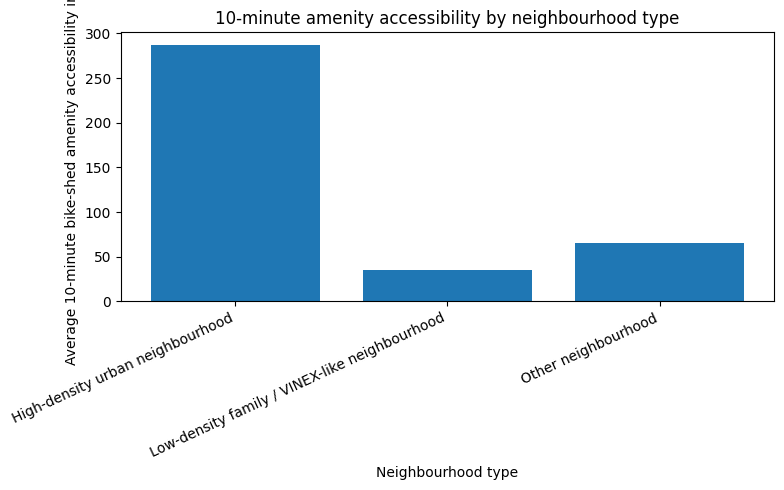

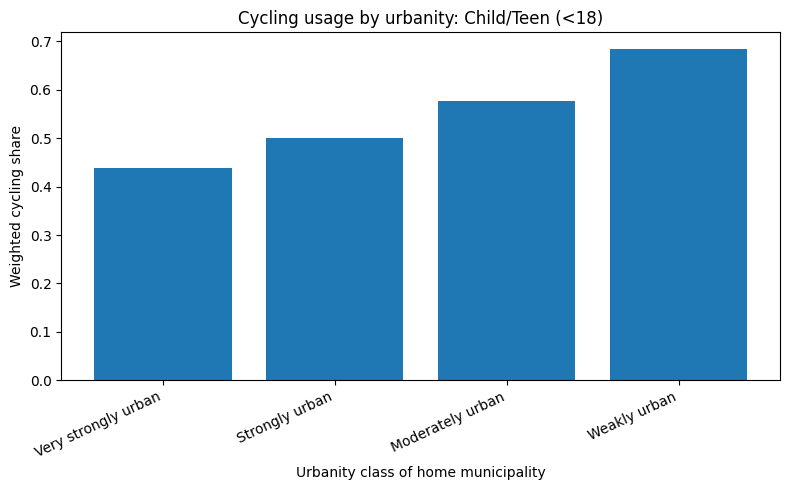

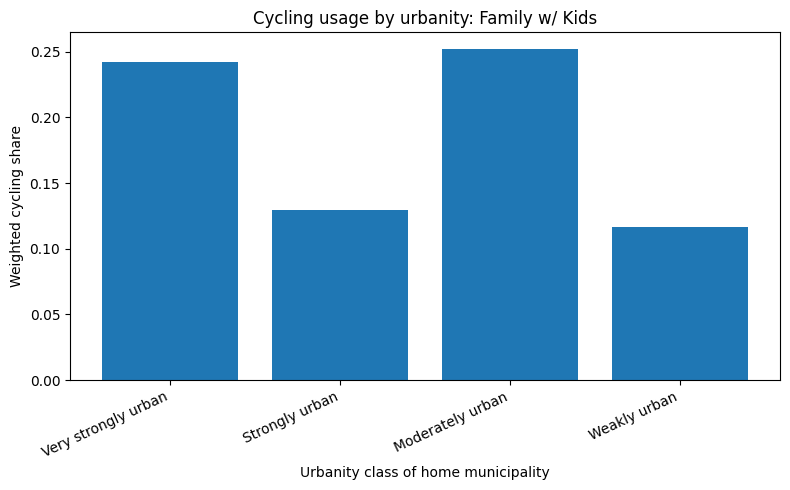

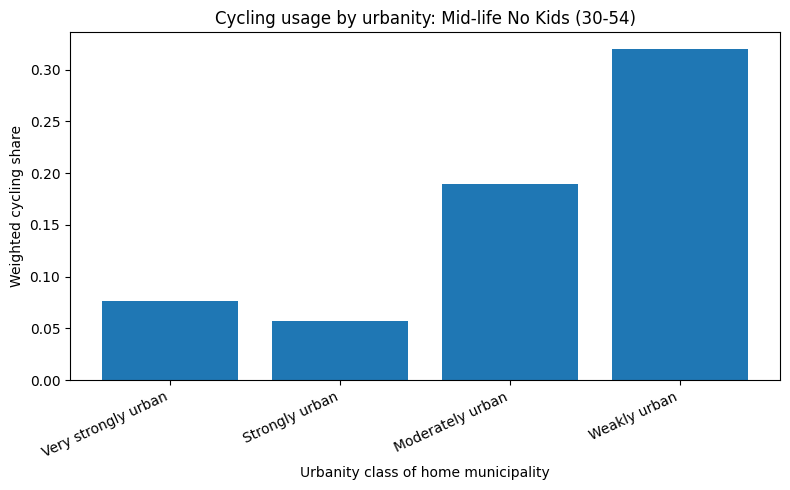

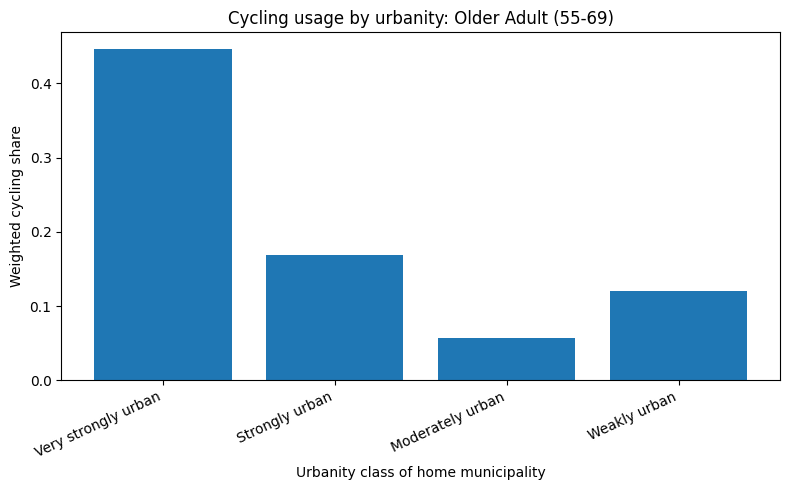

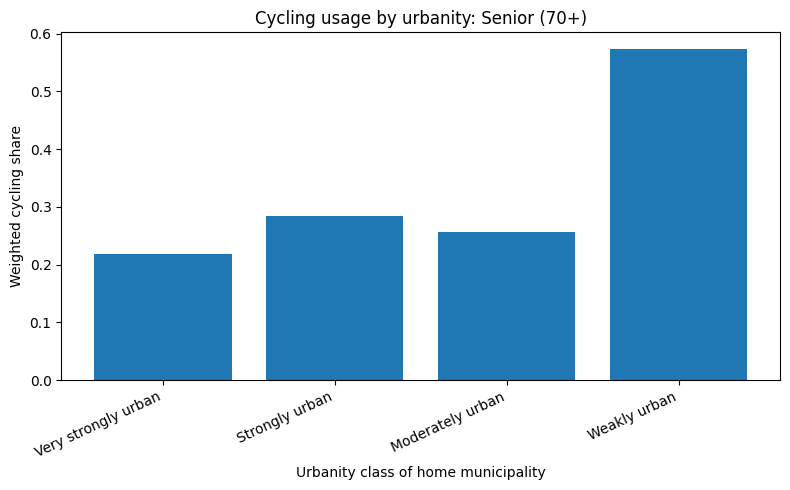

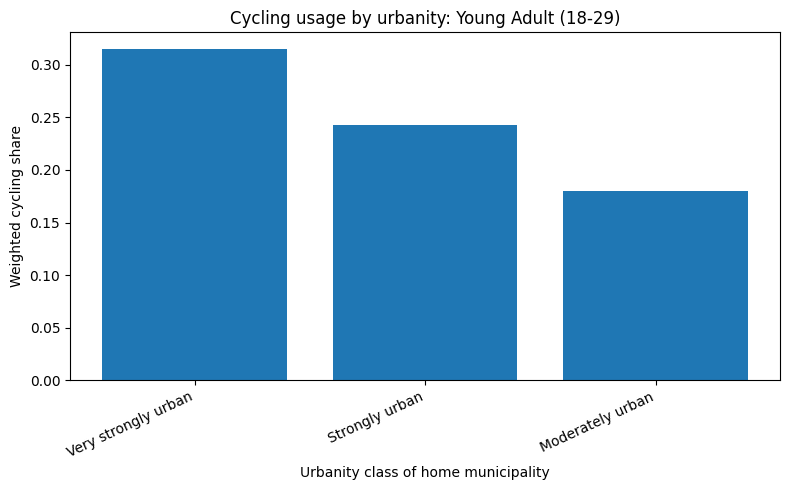

Child/Teen (<18): 1 municipios
Young Adult (18-29): 2 municipios
Family w/ Kids: 7 municipios
Mid-life No Kids (30-54): 3 municipios
Older Adult (55-69): 8 municipios
Senior (70+): 7 municipios


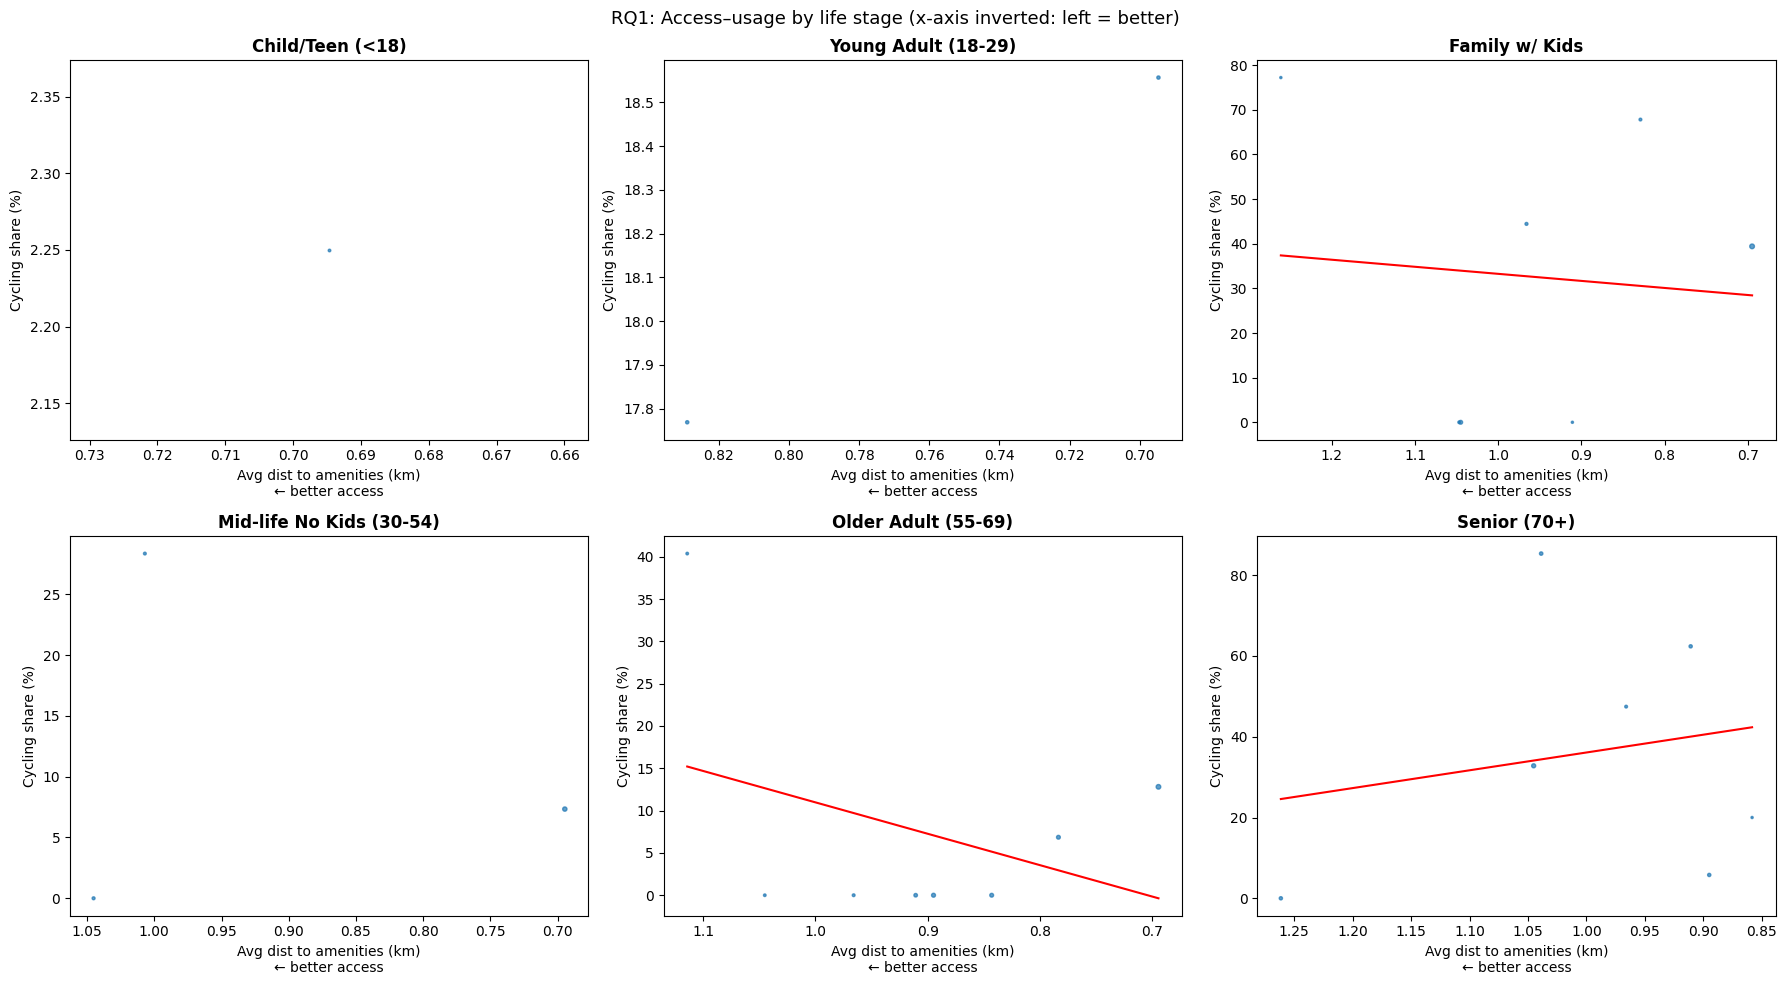

                   life_stage  Wogem_DANS24  n_trips_unweighted  cycling_share  avg_dist_km_y
2              Family w/ Kids           748                  15       0.051250            NaN
4                Senior (70+)           748                  11       0.204569            NaN
9         Older Adult (55-69)           753                   9       0.000000            NaN
10        Young Adult (18-29)           753                   6       0.000000            NaN
12   Mid-life No Kids (30-54)           757                   8       0.283507       1.006998
13           Child/Teen (<18)           758                   7       0.022500       0.694675
14             Family w/ Kids           758                  23       0.394126       0.694675
15   Mid-life No Kids (30-54)           758                  19       0.073369       0.694675
16        Older Adult (55-69)           758                  22       0.128111       0.694675
17        Young Adult (18-29)           758                 

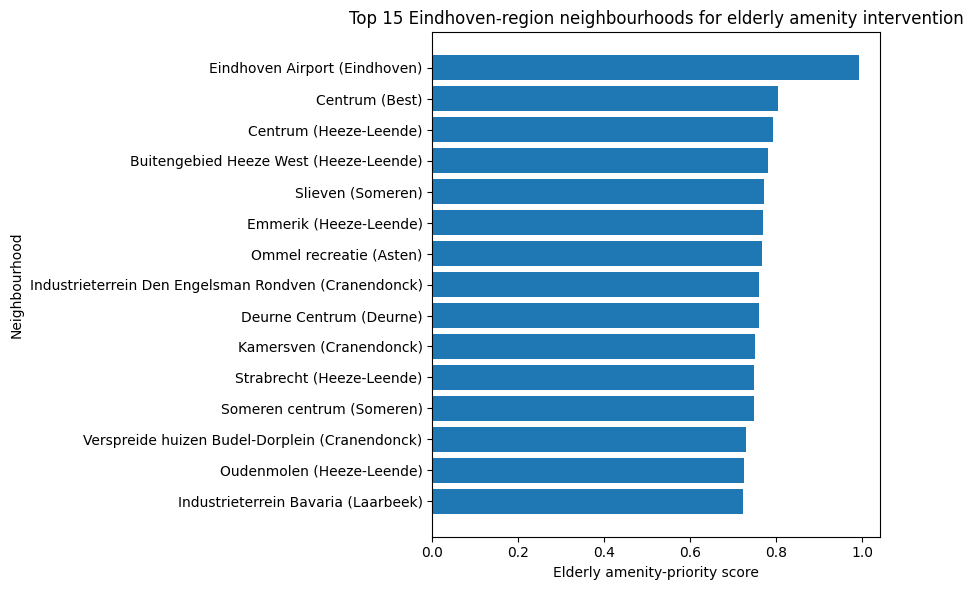

In [13]:
# -------------------------------------------------------
# Figure 1: Accessibility by neighbourhood type
# -------------------------------------------------------

fig_data = summary_eindhoven_type.copy()

plt.figure(figsize=(8, 5))
plt.bar(fig_data["neighbourhood_type"], fig_data["avg_total_access"])
plt.ylabel("Average 10-minute bike-shed amenity accessibility index")
plt.xlabel("Neighbourhood type")
plt.title("10-minute amenity accessibility by neighbourhood type")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUT / "fig_topic1_accessibility_by_neighbourhood_type.png", dpi=300)
plt.show()

# -------------------------------------------------------
# Figure 2: RQ1 cycling share by life stage and urbanity
# -------------------------------------------------------

odin_rq1 = pd.read_csv(OUT / "03_odin_rq1_life_stage_urbanity.csv")

sted_labels = {
    1: "Very strongly urban",
    2: "Strongly urban",
    3: "Moderately urban",
    4: "Weakly urban",
    5: "Non-urban"
}

odin_rq1["urbanity_label"] = odin_rq1["Sted"].map(sted_labels)
odin_rq1_plot = odin_rq1[odin_rq1["n_trips_unweighted"] >= 15].copy()

for life_stage in odin_rq1_plot["life_stage"].unique():
    sub = odin_rq1_plot[odin_rq1_plot["life_stage"] == life_stage].copy()
    sub = sub.sort_values("Sted")

    plt.figure(figsize=(8, 5))
    plt.bar(sub["urbanity_label"], sub["cycling_share"])
    plt.ylabel("Weighted cycling share")
    plt.xlabel("Urbanity class of home municipality")
    plt.title(f"Cycling usage by urbanity: {life_stage}")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    filename = f"fig_rq1_cycling_share_{life_stage.replace('/', '-').replace(' ', '_').replace('(', '').replace(')', '').replace('+', 'plus').replace('<', 'lt').replace('>', 'gt')}.png"
    plt.savefig(OUT / filename, dpi=300)
    plt.show()
# -------------------------------------------------------
# Figure 3: RQ1 access-usage scatter by life stage
# -------------------------------------------------------

rq1 = pd.read_csv(OUT / "table_rq1_municipality_access_usage.csv")
# Bajar filtro a n>=10 para ver más puntos
rq1_plot = rq1[rq1["n_trips_unweighted"] >= 5].copy()

LIFE_ORDER = ["Child/Teen (<18)", "Young Adult (18-29)", "Family w/ Kids",
              "Mid-life No Kids (30-54)", "Older Adult (55-69)", "Senior (70+)"]

def safe_filename(s):
    for char, rep in [('/', '-'), (' ', '_'), ('(', ''), (')', ''),
                      ('+', 'plus'), ('<', 'lt'), ('>', 'gt')]:
        s = s.replace(char, rep)
    return s

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
for ax, ls in zip(axes.flatten(), LIFE_ORDER):
    sub = rq1_plot[rq1_plot["life_stage"] == ls].dropna(subset=["avg_dist_km_y"])
    print(f"{ls}: {len(sub)} municipios")  # diagnóstico
    if len(sub) == 0:
        ax.set_title(f"{ls}\n(sin datos)", fontweight="bold")
        continue
    ax.scatter(sub["avg_dist_km_y"], sub["cycling_share"] * 100,
               s=sub["n_trips_unweighted"] / 2, alpha=0.7)
    if len(sub) >= 4:
        z = np.polyfit(sub["avg_dist_km_y"], sub["cycling_share"] * 100, 1)
        xs = np.linspace(sub["avg_dist_km_y"].min(), sub["avg_dist_km_y"].max(), 50)
        ax.plot(xs, np.poly1d(z)(xs), color="red", linewidth=1.5)
    ax.invert_xaxis()
    ax.set_title(ls, fontweight="bold")
    ax.set_xlabel("Avg dist to amenities (km)\n← better access")
    ax.set_ylabel("Cycling share (%)")

fig.suptitle("RQ1: Access–usage by life stage (x-axis inverted: left = better)", fontsize=13)
plt.tight_layout()
plt.savefig(OUT / f"fig_rq1_access_usage_fixed.png", dpi=300)
plt.show()

print(rq1_plot[["life_stage","Wogem_DANS24","n_trips_unweighted",
                 "cycling_share","avg_dist_km_y"]].to_string())
# -------------------------------------------------------
# Figure 4: RQ2 priority neighbourhoods
# -------------------------------------------------------

priority = pd.read_csv(OUT / "table_rq2_eindhoven_policy_priority_neighbourhoods.csv").head(15)

plt.figure(figsize=(9, 6))
plt.barh(priority["buurtnaam"] + " (" + priority["gemeente"] + ")", priority["elderly_amenity_priority_score"])
plt.xlabel("Elderly amenity-priority score")
plt.ylabel("Neighbourhood")
plt.title("Top 15 Eindhoven-region neighbourhoods for elderly amenity intervention")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUT / "fig_rq2_top15_elderly_amenity_priority.png", dpi=300)
plt.show()

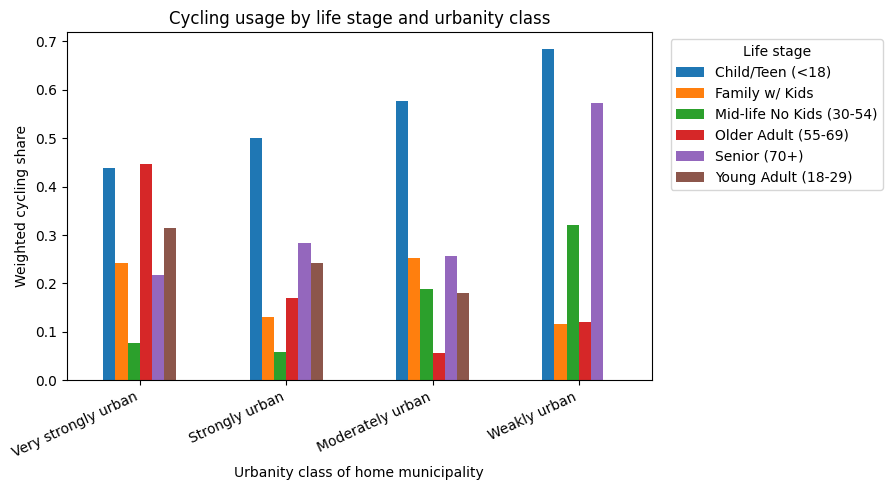

In [ ]:
odin_rq1 = pd.read_csv(OUT / "03_odin_rq1_life_stage_urbanity.csv")

sted_labels = {
    1: "Very strongly urban",
    2: "Strongly urban",
    3: "Moderately urban",
    4: "Weakly urban",
    5: "Non-urban"
}

odin_rq1["urbanity_label"] = odin_rq1["Sted"].map(sted_labels)

# Only keep groups with enough observations
plot_data = odin_rq1[odin_rq1["n_trips_unweighted"] >= 15].copy()

pivot = plot_data.pivot(
    index="urbanity_label",
    columns="life_stage",
    values="cycling_share"
)

order = ["Very strongly urban", "Strongly urban", "Moderately urban", "Weakly urban", "Non-urban"]
pivot = pivot.reindex([x for x in order if x in pivot.index])

ax = pivot.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Weighted cycling share")
ax.set_xlabel("Urbanity class of home municipality")
ax.set_title("Cycling usage by life stage and urbanity class")
ax.legend(title="Life stage", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUT / "fig_rq1_cycling_share_life_stage_urbanity_grouped.png", dpi=300)
plt.show()

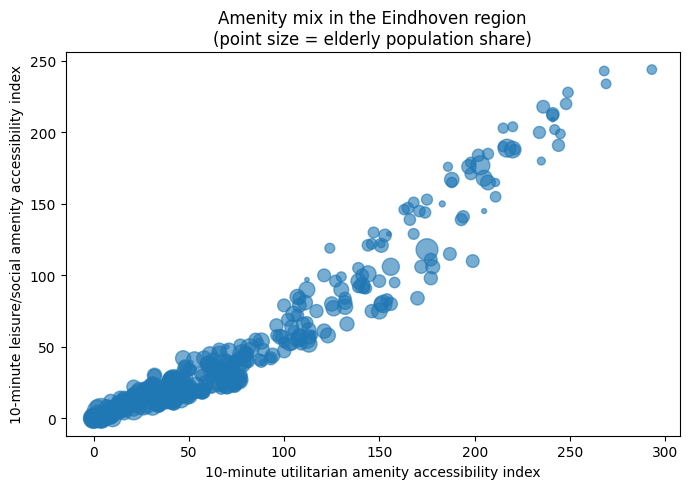

In [ ]:
access = pd.read_csv(OUT / "05_accessibility_context_buurten.csv")

eindhoven_region_codes = [
    743, 753, 762, 770, 772, 794, 820, 823, 847, 848, 858, 861, 866,
    1652, 1658, 1659, 1667, 1706, 1724, 1728, 1771
]

eindhoven = access[access["gm_code_int"].isin(eindhoven_region_codes)].copy()

plt.figure(figsize=(7, 5))
plt.scatter(
    eindhoven["bikeshed_utilitarian_amenities"],
    eindhoven["bikeshed_leisure_social_amenities"],
    s=(eindhoven["elderly_share"].fillna(0) * 400) + 10,
    alpha=0.6
)

plt.xlabel("10-minute utilitarian amenity accessibility index")
plt.ylabel("10-minute leisure/social amenity accessibility index")
plt.title("Amenity mix in the Eindhoven region\n(point size = elderly population share)")

plt.tight_layout()
plt.savefig(OUT / "fig_rq2_amenity_mix_eindhoven_region.png", dpi=300)
plt.show()

In [ ]:
LATEX_OUT = OUT / "latex_tables"
LATEX_OUT.mkdir(exist_ok=True)

# 1. Accessibility by neighbourhood type
access_type = pd.read_csv(OUT / "table_eindhoven_accessibility_by_neighbourhood_type.csv")

access_type_clean = access_type[[
    "neighbourhood_type",
    "n_buurten",
    "avg_total_access",
    "avg_utilitarian_access",
    "avg_leisure_social_access",
    "avg_elderly_share",
    "avg_family_household_share"
]].copy()

access_type_clean = access_type_clean.round({
    "avg_total_access": 1,
    "avg_utilitarian_access": 1,
    "avg_leisure_social_access": 1,
    "avg_elderly_share": 3,
    "avg_family_household_share": 3
})

access_type_clean.to_latex(
    LATEX_OUT / "table_accessibility_neighbourhood_type.tex",
    index=False,
    caption="Average 10-minute bike-shed accessibility by neighbourhood type in the Eindhoven region.",
    label="tab:access_neighbourhood_type",
    escape=True,
    float_format="%.3f"
)

# 2. ODiN cycling share by life stage and urbanity
odin_rq1 = pd.read_csv(OUT / "03_odin_rq1_life_stage_urbanity.csv")

sted_labels = {
    1: "Very strongly urban",
    2: "Strongly urban",
    3: "Moderately urban",
    4: "Weakly urban",
    5: "Non-urban"
}

odin_rq1["urbanity"] = odin_rq1["Sted"].map(sted_labels)

odin_rq1_clean = odin_rq1[
    odin_rq1["n_trips_unweighted"] >= 15
][[
    "life_stage",
    "urbanity",
    "n_trips_unweighted",
    "cycling_share",
    "car_share"
]].copy()

odin_rq1_clean = odin_rq1_clean.round({
    "cycling_share": 3,
    "car_share": 3
})

odin_rq1_clean.to_latex(
    LATEX_OUT / "table_odin_cycling_life_stage_urbanity.tex",
    index=False,
    caption="Weighted cycling and car shares by life stage and urbanity class in Noord-Brabant.",
    label="tab:cycling_life_stage_urbanity",
    escape=True,
    float_format="%.3f"
)

# 3. Elderly regional mobility summary
elderly_summary = pd.read_csv(OUT / "table_rq2_regional_elderly_car_dependency.csv")

elderly_summary_clean = elderly_summary[[
    "region",
    "n_trips_unweighted",
    "elderly_cycling_share",
    "elderly_car_share",
    "elderly_utilitarian_trip_share",
    "elderly_leisure_social_trip_share"
]].copy()

elderly_summary_clean = elderly_summary_clean.round({
    "elderly_cycling_share": 3,
    "elderly_car_share": 3,
    "elderly_utilitarian_trip_share": 3,
    "elderly_leisure_social_trip_share": 3
})

elderly_summary_clean.to_latex(
    LATEX_OUT / "table_elderly_regional_mobility.tex",
    index=False,
    caption="Weighted elderly mobility indicators for Zuidoost-Noord-Brabant.",
    label="tab:elderly_regional_mobility",
    escape=True,
    float_format="%.3f"
)

# 4. Top 10 priority neighbourhoods
priority = pd.read_csv(OUT / "table_rq2_eindhoven_policy_priority_neighbourhoods.csv")

priority_top10 = priority.head(10)[[
    "buurtnaam",
    "gemeente",
    "elderly_share",
    "bikeshed_utilitarian_amenities",
    "bikeshed_leisure_social_amenities",
    "elderly_amenity_priority_score"
]].copy()

priority_top10 = priority_top10.round({
    "elderly_share": 3,
    "bikeshed_utilitarian_amenities": 1,
    "bikeshed_leisure_social_amenities": 1,
    "elderly_amenity_priority_score": 3
})

priority_top10.to_latex(
    LATEX_OUT / "table_top10_priority_neighbourhoods.tex",
    index=False,
    caption="Top 10 Eindhoven-region neighbourhoods by elderly amenity-priority score.",
    label="tab:top10_priority_neighbourhoods",
    escape=True,
    float_format="%.3f"
)

print("Saved LaTeX tables to:", LATEX_OUT)

Saved LaTeX tables to: c:\Users\joane\Documents\MASTER\Q4\AI BUSINESS OPERATIONS\proyect\output\latex_tables
